In [1]:
import torch
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
import os
from itertools import product
from typing import List, Tuple
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix, roc_curve, auc
from torch.amp import GradScaler, autocast  # Set device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}, Device Name: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")
print(torch.__version__)  # E.g., 2.4.0+cu118
print(torch.cuda.is_available())  # Should print True
from torch.utils.data import random_split
from torch.backends import cudnn
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  
import torch._dynamo  
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.verbose = False        
import time
import random
import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)


Using device: cuda
CUDA Available: True, Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
2.10.0+cu130
True


In [2]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


In [4]:
torch.backends.cudnn.benchmark = True          # Huge speedup on fixed input size (256×256)
torch.backends.cuda.matmul.allow_tf32 = True   # +15–20% speed on Ampere/Ada (4060)
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')     # Use TensorFloat-32 where possible
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"   

# DATA

In [5]:
# import importlib
# import dataset
# # import testdataset
# importlib.reload(dataset)
# # importlib.reload(testdataset)
# # from traindataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path, transform as train_transform
# from dataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path


In [6]:
# train_transform = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.Pad(8, fill=255, padding_mode='constant'),
#     transforms.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.92, 1.08), fill=255),
#     transforms.RandomPerspective(distortion_scale=0.1, p=0.25, fill=255),
#     transforms.RandomApply(
#         [transforms.GaussianBlur(3, sigma=(0.1, 0.5))],
#         p=0.3
#     ),
#     transforms.Resize((64, 64)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,)),# <-- randomly erase patches
#     # transforms.RandomErasing(p=0.05, scale=(0.02,0.05), ratio=(0.3,3.3))  
# ])

# test_transform= transforms.Compose([
#     transforms.Resize((64, 64)),  # Resize to match FashionMNIST if needed
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))  # Standard normalization
# ])

# class TransformedDataset(Dataset):
#     def __init__(self, base_dataset, transform=None):
#         self.base_dataset = base_dataset
#         self.transform = transform

#     def __len__(self):
#         return len(self.base_dataset)

#     def __getitem__(self, idx):
#         img1, img2, label = self.base_dataset[idx]  # Gets PIL images and label from original
#         if self.transform:
#             img1 = self.transform(img1)
#             img2 = self.transform(img2)
#         return img1, img2, label
        

In [7]:

# all_dataset = SignatureVerificationDataset(
#     genuine_dir=genuine_extract_path,
#     forgery_dir=forgery_extract_path,
#     transform=test_transform
# )
# train_size = int(0.6 * len(all_dataset))
# test_size = len(all_dataset) - train_size
# train_dataset, test_dataset = random_split(all_dataset,[train_size,test_size])


# dataloader = DataLoader(
#     train_dataset, 
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=True,
#     num_workers=8,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )


In [8]:
# from testdataset import SignatureVerificationTestDataset, reference_extract_path, ques_extract_path,transform as test_transform

# testdataset = SignatureVerificationTestDataset(
#     reference_extract_path,
#     ques_extract_path,
#     transform=test_transform
# )
# test_size = int(0.6 * len(testdataset))
# val_size = len(testdataset) - test_size

# test_dataset, val_dataset = random_split(testdataset,[test_size,val_size])

# val_loader = DataLoader(val_dataset,
#                         batch_size=128,           # or 192/256 now that you use 64×64 images
#                         shuffle=False,
#                         num_workers=6,            # ← magic number for almost all gaming laptops
#                         pin_memory=True,          # ← very important with GPU
#                         prefetch_factor=2,
#                         persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=128,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )

In [9]:
# print(train_transform,"nrdd",test_transform)
import dataset
import importlib

Genuine authors: 268, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105', '118', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '230', '231', '233', '234', '235', '238', '240', '241', '243', '246', '249', '250', '251', '315', '318', '320', '328', '333', '341', '

In [39]:
importlib.reload(dataset)
from dataset import train_dataloader,val_dataloader,test_dataloader,train_dataset

Genuine authors: 268, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105', '118', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '230', '231', '233', '234', '235', '238', '240', '241', '243', '246', '249', '250', '251', '315', '318', '320', '328', '333', '341', '

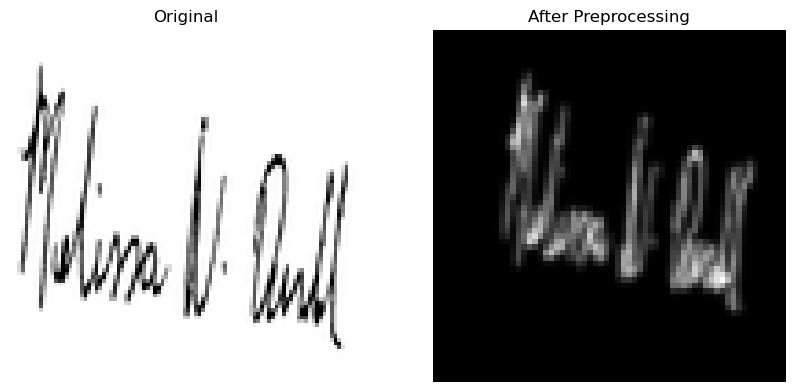

In [71]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Pad(8, fill=255, padding_mode='constant'),
    transforms.RandomAffine(degrees=15, translate=(0.08, 0.08), scale=(0.98, 1.1), fill=255),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.25, fill=255),
    transforms.RandomApply(
        [transforms.GaussianBlur(3, sigma=(0.1, 0.5))],
        p=0.3
    ),
    transforms.Resize((64, 64)),
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    # transforms.RandomErasing(p=0.05, scale=(0.02,0.05), ratio=(0.3,3.3))  
])# Load a raw signature
test_img = Image.open('./content/testfin/train_sig/full_forg/forgeries_042_22.png')

# Show before/after preprocessing
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

transformed = train_transform(test_img)
axes[1].imshow(transformed.squeeze(), cmap='gray')
axes[1].set_title('After Preprocessing')
axes[1].axis('off')

plt.show()

In [27]:
class ImprovedContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0, forgery_weight=1.5):
        super().__init__()
        self.margin = margin
        self.forgery_weight = forgery_weight
    
    def forward(self, emb1, emb2, label):
        distance = F.pairwise_distance(emb1, emb2)
        
        # Standard contrastive loss
        pos_loss = label * torch.pow(distance, 2)
        neg_loss = (1 - label) * torch.pow(
            torch.clamp(self.margin - distance, min=0.0), 2
        )
        
        # Weight forgery pairs more heavily
        weights = torch.ones_like(label)
        weights[label == 0] = self.forgery_weight  # Forgeries get 1.5x weight
        
        # Hard negative mining for forgeries
        if (label == 0).sum() > 0:
            neg_distances = distance[label == 0]
            median_neg = neg_distances.median()
            
            # Hard forgeries: those close to genuine (small distance)
            hard_forgery_mask = (label == 0) & (distance < median_neg)
            weights[hard_forgery_mask] = 2.5  # Extra hard forgeries: 2.5x weight
        
        loss = (pos_loss + neg_loss) * weights
        return loss.mean()

# Use it
criterion = ImprovedContrastiveLoss(margin=0.8, forgery_weight=1.5)

In [28]:
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
margin=0.6
lr=0.01
threshold=0.7
from model import model_final as model,device
model = torch.compile(model, mode="reduce-overhead")   # or "default"
model = model.to(device)


In [29]:
import torch.optim.lr_scheduler as lr_scheduler
# criterion = ContrastiveLoss(margin=margin)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)  # AdamW > Adam
scaler = GradScaler()
# After optimizer definition
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # 'min' for minimizing loss; use 'max' if monitoring accuracy
    factor=0.01,       # Multiply lr by this (e.g., 0.0001 → 0.00001)
    patience=3,
    threshold=1e-4,   # Wait this many epochs without improvement
    min_lr=1e-6 # Optional: Minimum lr to stop reducing below
)
best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_margin{margin}_size64_lr{lr}.pt"


In [32]:
# Training with mixed precision
best_val_loss = float('inf')
early_stop_counter = 0
patience = 10
min_delta = 0.0005
num_epochs = 30

class EfficientCenterAttentionLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super().__init__()
        self.alpha = alpha
        self.img1_output = None
        self.img2_output = None
        self.current_forward = 'img1'  # Track which image we're processing
    
    def hook_fn(self, module, input, output):
        """Store block4 output based on which forward pass"""
        if self.current_forward == 'img1':
            self.img1_output = output.detach().clone()
        else:  # img2
            self.img2_output = output.detach().clone()


# Setup
center_loss_fn = EfficientCenterAttentionLoss(alpha=0.05)
model_unwrapped = model._orig_mod if hasattr(model, '_orig_mod') else model
handle = model_unwrapped.block4.register_forward_hook(center_loss_fn.hook_fn)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_main_loss = 0.0
    epoch_center_loss = 0.0
    num_batches = 0
    num_center_batches = 0
    start_time = time.time()

    for img1, img2, labels in train_dataloader:
        img1, img2, labels = (
            img1.to(device, non_blocking=True),
            img2.to(device, non_blocking=True),
            labels.to(device, non_blocking=True)
        )
        
        forgery_mask = labels == 0
        has_forgeries = forgery_mask.sum() > 0
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast('cuda', dtype=torch.bfloat16):
            # Forward img1
            center_loss_fn.current_forward = 'img1'
            emb1 = model(img1)
            
            # Forward img2
            center_loss_fn.current_forward = 'img2'
            emb2 = model(img2)
            
            main_loss = criterion(emb1, emb2, labels)
            
            # Center loss ONLY on img2 forgeries
            if has_forgeries and center_loss_fn.img2_output is not None:
                # Extract forgery activations from img2
                forgery_act = center_loss_fn.img2_output[forgery_mask]
                
                B_forg, C, H, W = forgery_act.shape
                
                # Center mask
                center_mask = torch.zeros((H, W), device=forgery_act.device, dtype=forgery_act.dtype)
                center_mask[H//4:3*H//4, W//4:3*W//4] = 1.0
                
                # Spatial attention
                spatial_att = torch.mean(forgery_act, dim=1)
                spatial_att_flat = spatial_att.view(B_forg, -1)
                spatial_att_norm = F.softmax(spatial_att_flat, dim=1).view(B_forg, H, W)
                
                # Center focus
                center_focus = (spatial_att_norm * center_mask).sum(dim=(1, 2))
                att_loss = -torch.log(center_focus + 1e-8).mean()
                
                total_loss = main_loss + 0.05 * att_loss
                epoch_center_loss += att_loss.item()
                num_center_batches += 1
            else:
                total_loss = main_loss
        
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += total_loss.item()
        epoch_main_loss += main_loss.item()
        num_batches += 1

    epoch_time = time.time() - start_time
    avg_train_loss = epoch_loss / num_batches
    avg_main_loss = epoch_main_loss / num_batches
    avg_center_loss = epoch_center_loss / num_center_batches if num_center_batches > 0 else 0

    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Loss: {avg_train_loss:.4f} "
          f"(Main: {avg_main_loss:.4f}, Center: {avg_center_loss:.4f}) | "
          f"Time: {epoch_time:.1f}s | "
          f"Current LR: {optimizer.param_groups[0]['lr']:.6f}  | "
          f"Batches w/ center: {num_center_batches}/{num_batches}")

    # ─── Validation every 2 epochs ───────────────────────────────────
    # ─── Validation every 4 epochs ───────────────────────────────────
    if (epoch + 1) % 1 == 0:
        model.eval()
        val_losses = []
        distance_all = []
        labels_all = []
        
        with torch.no_grad():
            for img1, img2, labels in val_dataloader:
                # Use only first reference
                img1 = img1.to(device, non_blocking=True)
                img2 = img2.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
            
                with autocast("cuda", dtype=torch.bfloat16):
                    emb1 = model(img1)
                    emb2 = model(img2)
            
                distance = F.pairwise_distance(emb1, emb2)
                distance_all.append(distance)
                labels_all.append(labels)
            
                val_batch_loss = criterion(emb1, emb2, labels)
                val_losses.append(val_batch_loss.item())

        # Aggregate
        distance_all = torch.cat(distance_all)
        labels_all = torch.cat(labels_all)
        avg_val_loss = sum(val_losses) / len(val_losses)

        # ─── Threshold tuning (FIXED!) ───────────────────────────────
        y_true = labels_all.cpu().numpy()  # ← THIS WAS MISSING!
        
        # Method 1: Simple negation approach (recommended)
        similarity_scores = -distance_all.cpu().numpy()
        fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = -thresholds_roc[optimal_idx]  # Convert back to distance

        eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
        print(f"EER: {eer:.4f}")  # Aim for <0.1 for good models
        y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)

        print(f"   Val Loss: {avg_val_loss:.6f} | "
              f"Acc: {accuracy_score(y_true, y_pred):.4f} | "
              f"Threshold: {optimal_threshold:.3f} | "  # ← FIXED variable name
              f"Genuine: {distance_all[labels_all==1].mean():.3f} | "
              f"Forged: {distance_all[labels_all==0].mean():.3f}")
        
        scheduler.step(avg_val_loss)

        # ─── Early Stopping ──────────────────────────────────────────
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"   → New best val loss: {best_val_loss:.6f} (saved)")
        else:
            early_stop_counter += 1
            print(f"   → No improvement. Patience: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break

        # Cleanup (FIXED!)
        del distance_all, labels_all, y_true, y_pred
        torch.cuda.empty_cache()

# ─── Load best model ─────────────────────────────────────────────────
print("Loading best model for final evaluation...")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

Epoch  1/30 | Loss: 0.2512 (Main: 0.1847, Center: 1.3300) | Time: 63.8s | Current LR: 0.010000  | Batches w/ center: 942/942
EER: 0.1957
   Val Loss: 0.166704 | Acc: 0.8107 | Threshold: 0.363 | Genuine: 0.220 | Forged: 0.644
   → New best val loss: 0.166704 (saved)
Epoch  2/30 | Loss: 0.2268 (Main: 0.1620, Center: 1.2963) | Time: 63.4s | Current LR: 0.010000  | Batches w/ center: 942/942
EER: 0.2000
   Val Loss: 0.182226 | Acc: 0.8072 | Threshold: 0.334 | Genuine: 0.193 | Forged: 0.606
   → No improvement. Patience: 1/10
Epoch  3/30 | Loss: 0.2166 (Main: 0.1523, Center: 1.2855) | Time: 60.7s | Current LR: 0.010000  | Batches w/ center: 942/942
EER: 0.1754
   Val Loss: 0.138157 | Acc: 0.8275 | Threshold: 0.424 | Genuine: 0.261 | Forged: 0.808
   → New best val loss: 0.138157 (saved)
Epoch  4/30 | Loss: 0.2047 (Main: 0.1413, Center: 1.2676) | Time: 61.0s | Current LR: 0.010000  | Batches w/ center: 942/942
EER: 0.1653
   Val Loss: 0.128124 | Acc: 0.8386 | Threshold: 0.420 | Genuine: 0.26

OptimizedModule(
  (_orig_mod): SiameseCNN(
    (block1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): PReLU(num_parameters=1)
      (6): SpatialAttention(
        (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (sigmoid): Sigmoid()
      )
      (7): Dropout2d(p=0.1, inplace=False)
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Co

✓ Saliency visualization module loaded
✓ Model loaded from: second_saved_models/savedmodels/dropoutCNN/best_siamese_margin0.6_size64_lr0.01.pt
Testing visualizations...
✓ Saliency: shapes=(64, 64), distance=0.1176
✓ Grad-CAM: shapes=(64, 64), max=1.0000
  Using: Library (Grad-CAM++)

✓ All visualizations working!

Visualizing sample pairs...


C:\Users\gupta\7th SEM\Project\Signature\saliency_visualization.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: sample_visualizations/pair_0_genuine pair_dist0.388.png


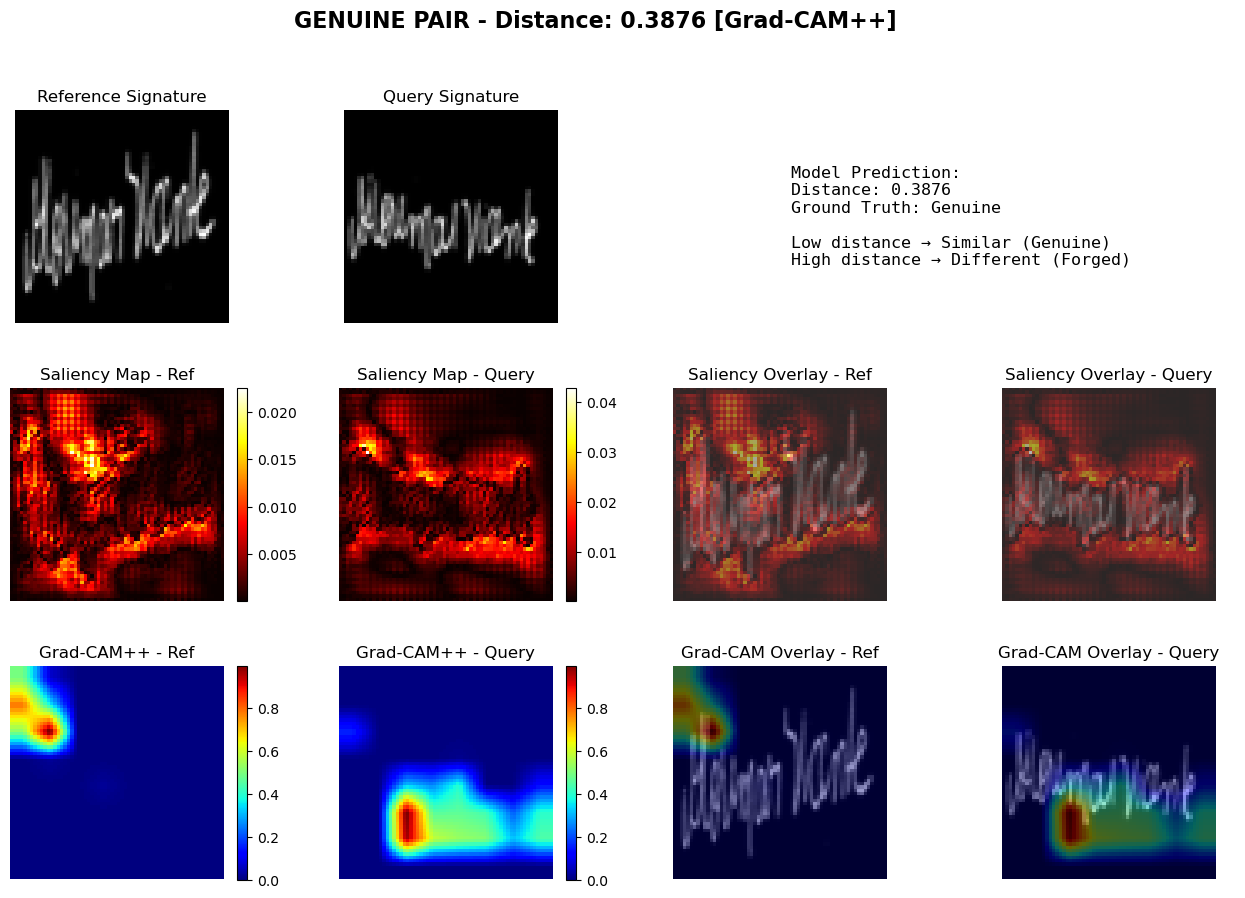

Saved: sample_visualizations/pair_1_genuine pair_dist0.315.png


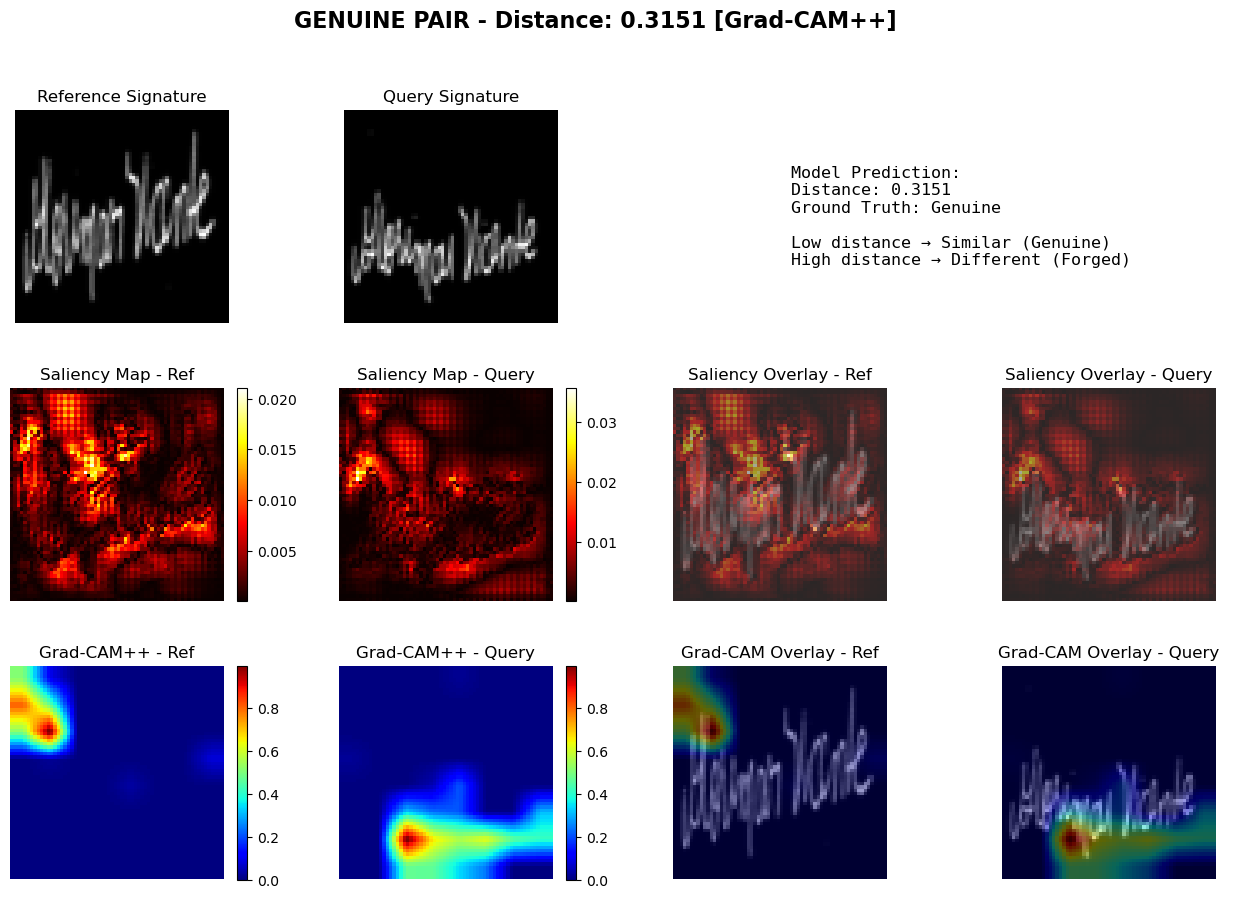

Saved: sample_visualizations/pair_2_genuine pair_dist0.351.png


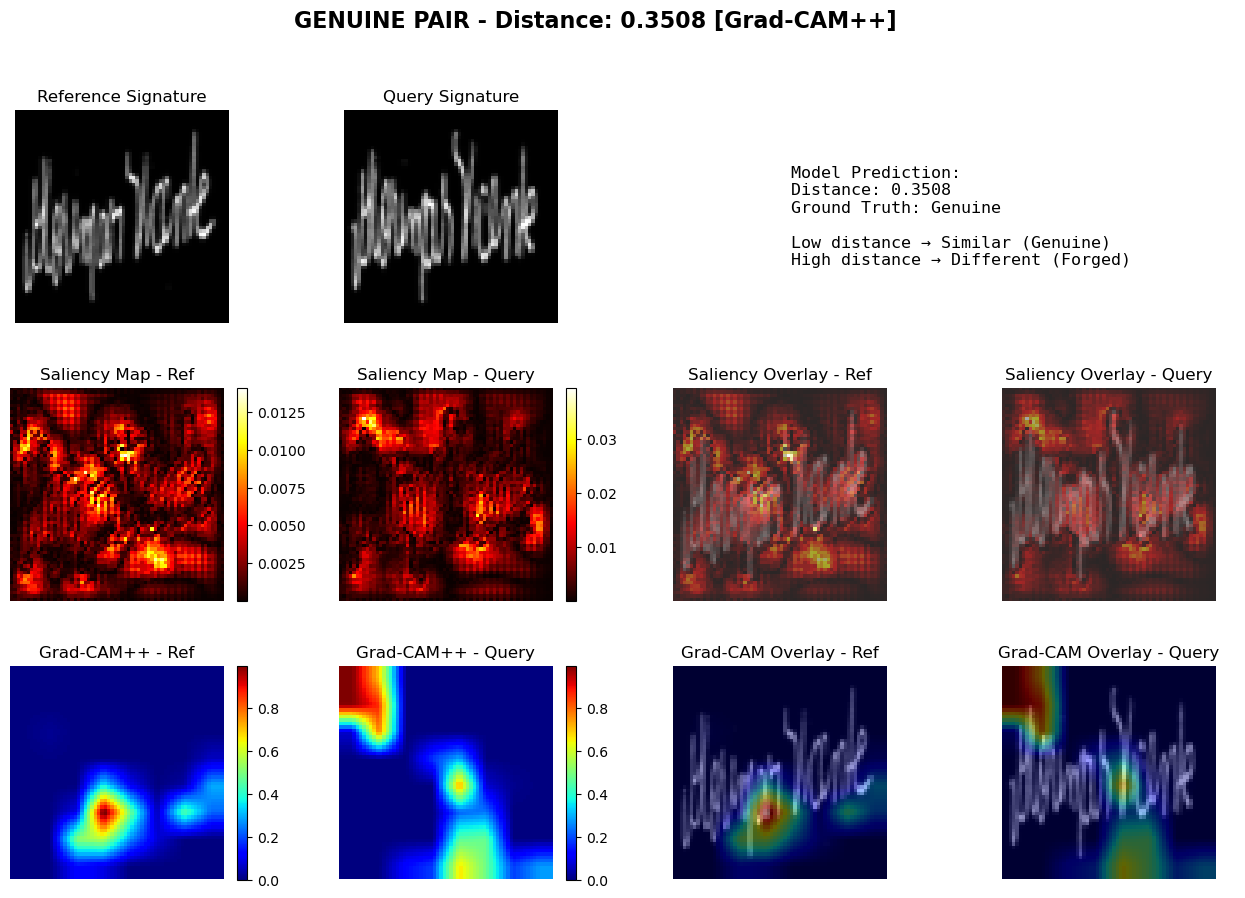

Saved: sample_visualizations/pair_3_forged pair_dist0.395.png


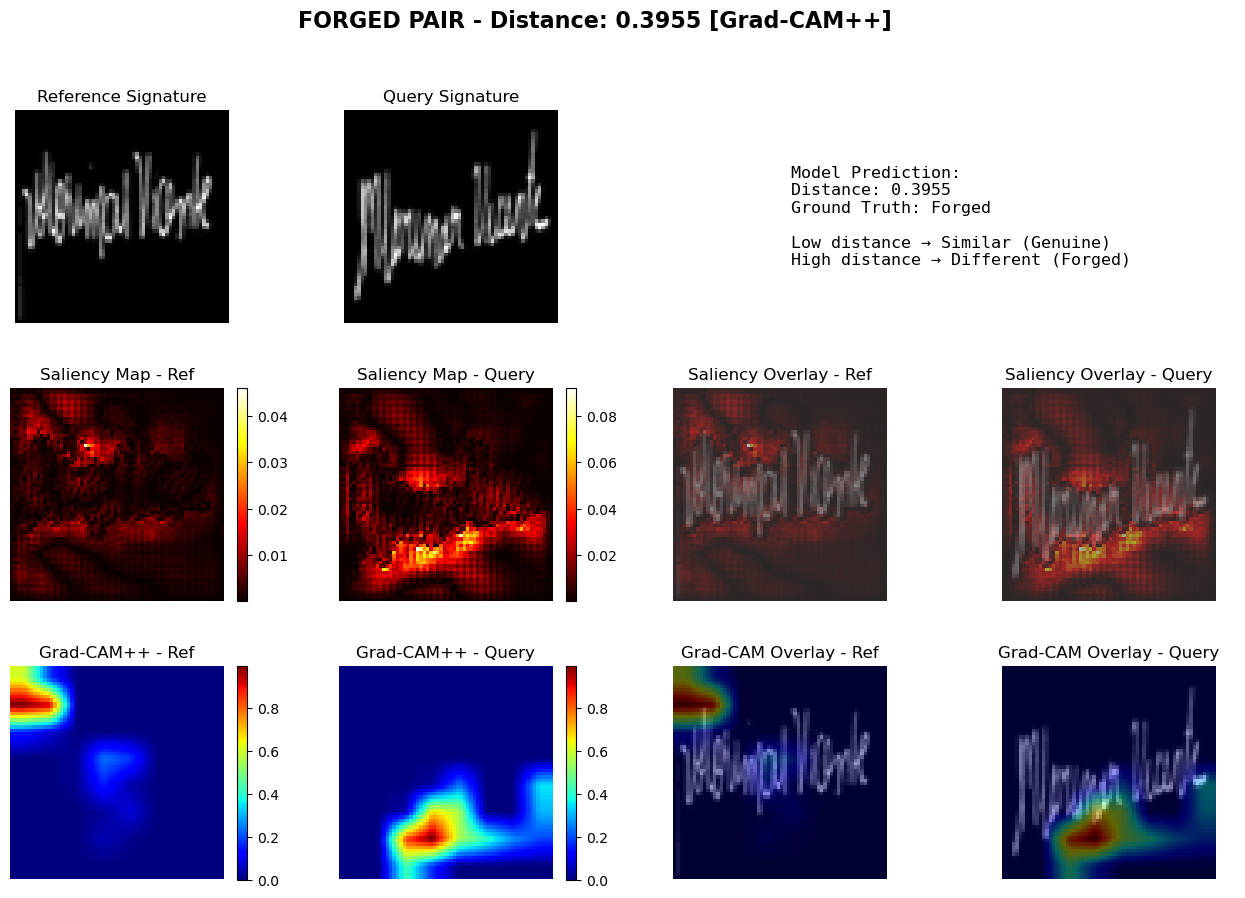

Saved: sample_visualizations/pair_4_forged pair_dist0.620.png


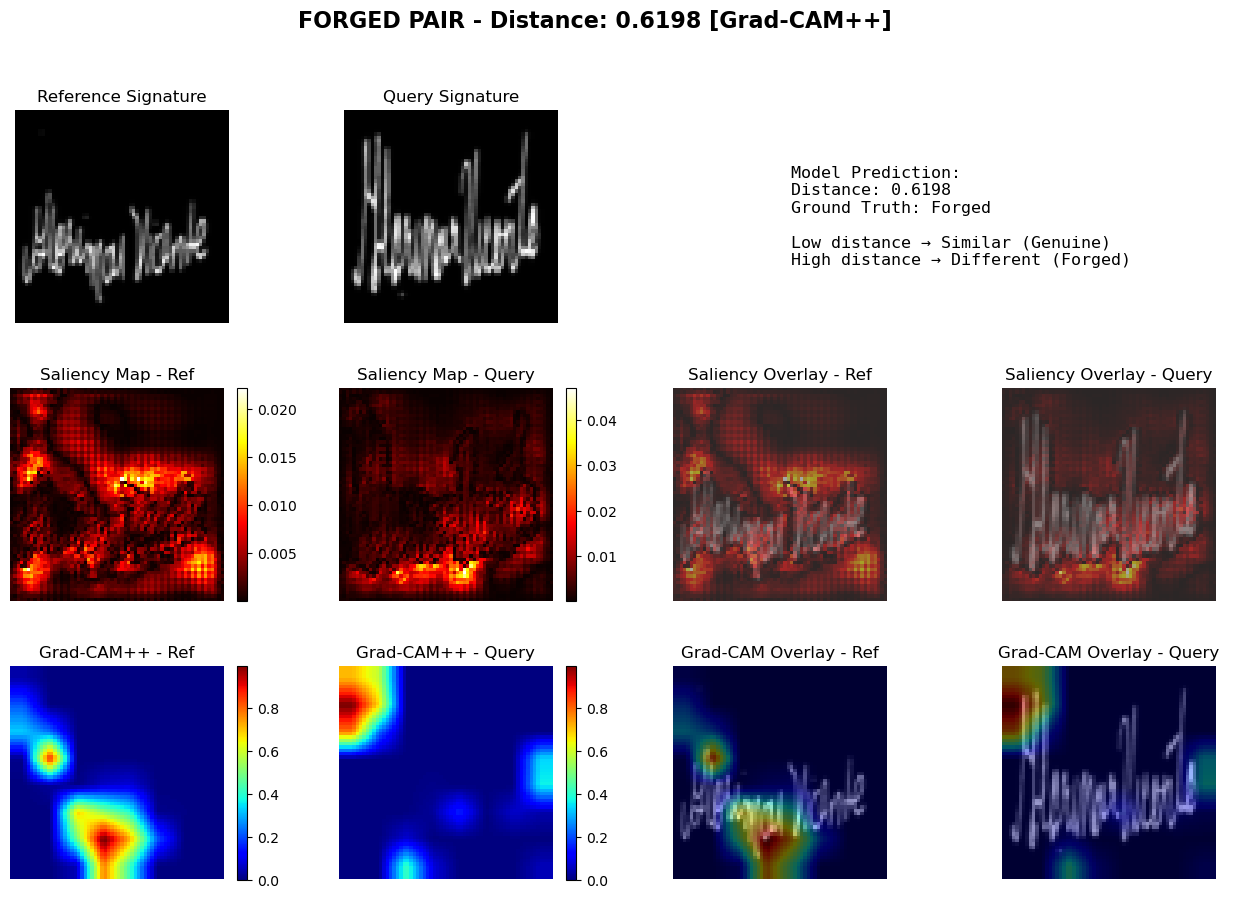

✓ Visualized 5 pairs

Computing statistical focus analysis...


Computing saliency:   3%|█▋                                                             | 2/73 [00:13<08:01,  6.78s/it]


✓ Collected 50 genuine, 50 forged


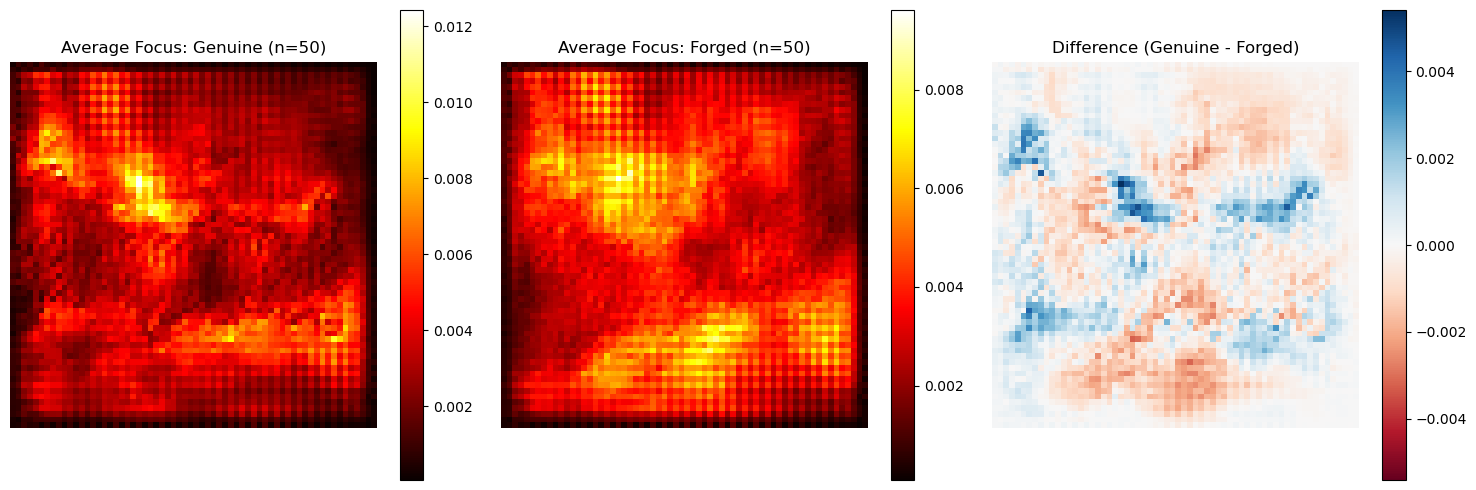


FOCUS STATISTICS

Genuine: Center/Edge = 1.42
Forged:  Center/Edge = 1.38

⚠️ WARNING: Model may learn edge artifacts

✓ All analysis complete!


In [36]:

# ─── Cell 1: Import and Setup ─────────────────────────────────────────
import saliency_visualization
import importlib
from tqdm import tqdm

# Reload to get latest changes
importlib.reload(saliency_visualization)
from saliency_visualization import SaliencyVisualizer, analyze_model_focus

# Load your best model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("✓ Saliency visualization module loaded")
print(f"✓ Model loaded from: {best_model_path}")


# ─── Cell 2: Quick Test ───────────────────────────────────────────────
print("Testing visualizations...")

visualizer = SaliencyVisualizer(model, device)

for img1, img2, labels in test_dataloader:
    try:
        # Test saliency
        sal1, sal2, dist = visualizer.compute_saliency(
            img1[0:1].clone(), 
            img2[0:1].clone(), 
            labels[0].item()
        )
        print(f"✓ Saliency: shapes={sal1.shape}, distance={dist:.4f}")
        
        # Test Grad-CAM
        gradcam1, gradcam2 = visualizer.compute_gradcam_library(
            img1[0:1].clone(),
            img2[0:1].clone()
        )
        print(f"✓ Grad-CAM: shapes={gradcam1.shape}, max={gradcam1.max():.4f}")
        print(f"  Using: {'Library (Grad-CAM++)' if visualizer.use_library else 'Fallback'}")
        
        print("\n✓ All visualizations working!")
        break
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        break


# ─── Cell 3: Visualize Sample Pairs ───────────────────────────────────
print("\nVisualizing sample pairs...")

visualizer = SaliencyVisualizer(model, device)

sample_count = 0
genuine_count = 0
forged_count = 0

for img1, img2, labels in val_dataloader:
    for i in range(len(labels)):
        if sample_count >= 5:
            break
        
        label = labels[i].item()
        
        if label == 1 and genuine_count < 3:
            visualizer.visualize_pair(
                img1[i:i+1].clone(),
                img2[i:i+1].clone(),
                label,
                save_path='sample_visualizations',
                pair_idx=sample_count
            )
            genuine_count += 1
            sample_count += 1
        elif label == 0 and forged_count < 2:
            visualizer.visualize_pair(
                img1[i:i+1].clone(),
                img2[i:i+1].clone(),
                label,
                save_path='sample_visualizations',
                pair_idx=sample_count
            )
            forged_count += 1
            sample_count += 1
    
    if sample_count >= 5:
        break

print(f"✓ Visualized {sample_count} pairs")


# ─── Cell 4: Statistical Focus Analysis ───────────────────────────────
print("\nComputing statistical focus analysis...")

visualizer = SaliencyVisualizer(model, device)

genuine_saliency_maps = []
forged_saliency_maps = []
num_analyze = 50

genuine_count = 0
forged_count = 0

for img1, img2, labels in tqdm(val_dataloader, desc="Computing saliency"):
    for i in range(len(labels)):
        if genuine_count >= num_analyze and forged_count >= num_analyze:
            break
        
        label = labels[i].item()
        
        try:
            sal1, sal2, dist = visualizer.compute_saliency(
                img1[i:i+1].clone(),
                img2[i:i+1].clone(),
                label
            )
            
            if sal1.shape != (64, 64) or sal2.shape != (64, 64):
                continue
            
            avg_sal = (sal1 + sal2) / 2
            
            if label == 1 and genuine_count < num_analyze:
                genuine_saliency_maps.append(avg_sal)
                genuine_count += 1
            elif label == 0 and forged_count < num_analyze:
                forged_saliency_maps.append(avg_sal)
                forged_count += 1
        except:
            continue
    
    if genuine_count >= num_analyze and forged_count >= num_analyze:
        break

print(f"✓ Collected {len(genuine_saliency_maps)} genuine, {len(forged_saliency_maps)} forged")

# Compute and visualize
if len(genuine_saliency_maps) > 0 and len(forged_saliency_maps) > 0:
    genuine_avg = np.mean(genuine_saliency_maps, axis=0)
    forged_avg = np.mean(forged_saliency_maps, axis=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    im0 = axes[0].imshow(genuine_avg, cmap='hot')
    axes[0].set_title(f'Average Focus: Genuine (n={len(genuine_saliency_maps)})')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(forged_avg, cmap='hot')
    axes[1].set_title(f'Average Focus: Forged (n={len(forged_saliency_maps)})')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    difference = genuine_avg - forged_avg
    vmax = max(abs(difference.min()), abs(difference.max()))
    im2 = axes[2].imshow(difference, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Difference (Genuine - Forged)')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    plt.savefig('average_saliency_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    def compute_focus_stats(saliency_maps):
        center_vals, edge_vals = [], []
        for sal in saliency_maps:
            h, w = sal.shape
            center_mask = np.zeros_like(sal)
            center_mask[h//4:3*h//4, w//4:3*w//4] = 1
            center_vals.append(sal[center_mask == 1].mean())
            edge_vals.append(sal[center_mask == 0].mean())
        return {
            'center_mean': np.mean(center_vals),
            'edge_mean': np.mean(edge_vals),
            'ratio': np.mean(center_vals) / (np.mean(edge_vals) + 1e-8)
        }
    
    genuine_stats = compute_focus_stats(genuine_saliency_maps)
    forged_stats = compute_focus_stats(forged_saliency_maps)
    
    print("\n" + "="*60)
    print("FOCUS STATISTICS")
    print("="*60)
    print(f"\nGenuine: Center/Edge = {genuine_stats['ratio']:.2f}")
    print(f"Forged:  Center/Edge = {forged_stats['ratio']:.2f}")
    
    if genuine_stats['ratio'] > 2.0 and forged_stats['ratio'] > 2.0:
        print("\n✓ EXCELLENT: Model focuses on signature content")
    elif genuine_stats['ratio'] > 1.5 and forged_stats['ratio'] > 1.5:
        print("\n✓ GOOD: Model focuses on center")
    else:
        print("\n⚠️ WARNING: Model may learn edge artifacts")


print("\n✓ All analysis complete!")

Validation Accuracy (optimal threshold=0.505): 0.7811
Accuracy:  0.7811
Precision: 0.7447
Recall:    0.8552
F1-score:  0.7962
AUC:       0.8578

Distance Statistics:
  Genuine mean: 0.303 ± 0.189
  Forged mean:  0.837 ± 0.468


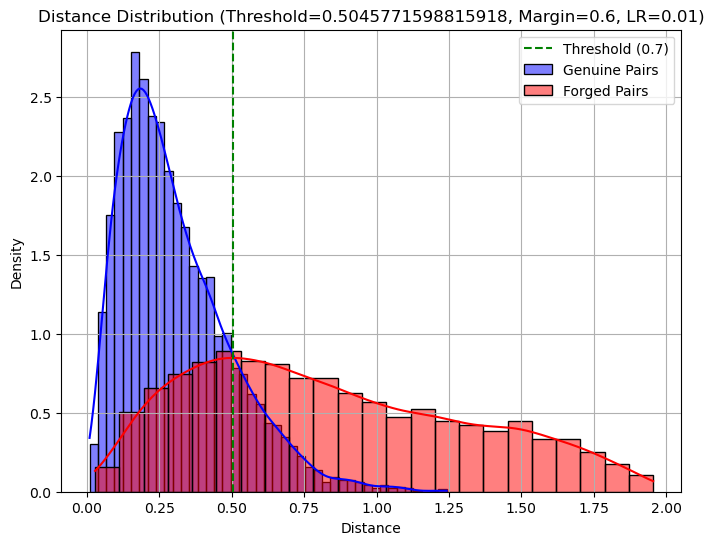

In [38]:
val_losses = []
distance_all = []
labels_all = []
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
with torch.no_grad():
    for img1_array, img2, labels in test_dataloader:
        # Use only first reference
        img1 = img1_array.to(device, non_blocking=True)
        #img1 = img1_array.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
    
        with autocast("cuda", dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
    
        distance = F.pairwise_distance(emb1, emb2)
        distance_all.append(distance)
        labels_all.append(labels)
    
        val_batch_loss = criterion(emb1, emb2, labels)
        val_losses.append(val_batch_loss.item())

# Aggregate
distance_all = torch.cat(distance_all)
labels_all = torch.cat(labels_all)
avg_val_loss = sum(val_losses) / len(val_losses)

# ─── Threshold tuning (FIXED!) ───────────────────────────────
y_true = labels_all.cpu().numpy()  # ← THIS WAS MISSING!

# Method 1: Simple negation approach (recommended)
similarity_scores = -distance_all.cpu().numpy()
fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds_roc[optimal_idx]  # Convert back to distance

y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)
y_pred_optimal = (distance_all.cpu().numpy() < optimal_threshold).astype(int)

print(f"Validation Accuracy (optimal threshold={optimal_threshold:.3f}): {accuracy_score(y_true, y_pred_optimal):.4f}")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_true, similarity_scores):.4f}")
print(f"\nDistance Statistics:")
print(f"  Genuine mean: {distance_all[labels_all==1].mean():.3f} ± {distance_all[labels_all==1].std():.3f}")
print(f"  Forged mean:  {distance_all[labels_all==0].mean():.3f} ± {distance_all[labels_all==0].std():.3f}")
indices = np.random.permutation(len(labels_all))
distance_np = distance_all[indices].cpu().numpy()
labels_np = labels_all[indices].cpu().numpy()
distance_genuine = distance_np[labels_np == 1].tolist()
distance_forged = distance_np[labels_np == 0].tolist()

plt.figure(figsize=(8, 6))
sns.histplot(distance_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
sns.histplot(distance_forged, color='red', label='Forged Pairs', kde=True, stat='density')
plt.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.title(f'Distance Distribution (Threshold={optimal_threshold}, Margin={margin}, LR={lr})')
plt.legend()
plt.grid(True)
# plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
plt.show()  # Display the plot
plt.close()